In [145]:
class Value:
    def __init__(self,data,_children=(),label="",_op=""):
        self.data = data
        self._prev = _children
        self.label = label
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other))
        return out
    
    def __radd__(self, other):
        return self.data + other.data
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other))
        return out 
    
    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"Value(data={self.data})"
    
  

In [146]:
a = Value(2)
b = Value(3)
c = a+b
c._prev


(Value(data=2), Value(data=3))

In [ ]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

from graphviz import Digraph

def draw_dot(root):
    dot = Digraph(format='SVG',graph_attr={"rankdir":"LR"})
    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{%s | data %.4f}" % (n.label,n.data),shape='record')
        # dot.node(name=uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')

        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot



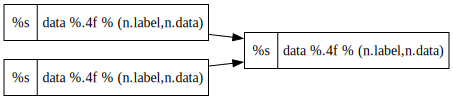

In [150]:
draw_dot(c)